# ARIMA Modeling

### Dataset

We will be using the Walmart Sales Forecasting dataset to demonstrate the application of time series modeling and ARIMA techniques for retail demand forecasting. The dataset contains weekly sales data across multiple Walmart stores and departments over a multi-year period.

The data consists of over 400,000 observations of historical weekly sales, along with store identifiers, department identifiers, and holiday indicators. For this analysis, we aggregate total weekly sales across all stores and departments to create a single univariate time series suitable for ARIMA modeling.

This dataset provides a practical real-world example of retail seasonality, holiday effects, and trend behavior, allowing us to explore concepts such as stationarity, autocorrelation, differencing, and forecasting accuracy.

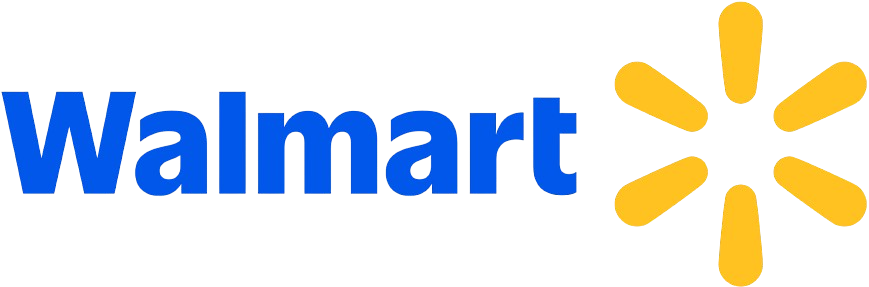

In [ ]:
#Import Libraries and data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
%matplotlib inline

In [ ]:
#Import data from Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "aslanahmedov/walmart-sales-forecast",
    "train.csv",
)

print("Shape:", df.shape)
df.head()

/tmp/ipython-input-856931217.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 2.91M/2.91M [00:00<00:00, 53.4MB/s]

Extracting zip of train.csv...


Shape: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index so ARIMA treats it as a time series
df = df.set_index("Date")

# Sort chronologically since ARIMA requires ordered time
df = df.sort_index()

df.head()

,Store,Dept,Weekly_Sales,IsHoliday
Date,,,,
2010-02-05,1,1,24924.50,False
2010-02-05,29,5,15552.08,False
2010-02-05,29,6,3200.22,False
2010-02-05,29,7,10820.05,False
2010-02-05,29,8,20055.64,False


### Aggregation

ARIMA requires ONE value per time step

We aggregate across all stores and departments to create a single univariate time series (Total Weekly Sales)



In [ ]:
weekly_sales = df["Weekly_Sales"].groupby(df.index).sum()

print("Number of weeks:", weekly_sales.shape[0])
weekly_sales.head()


Number of weeks: 143


,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


### Line Plot

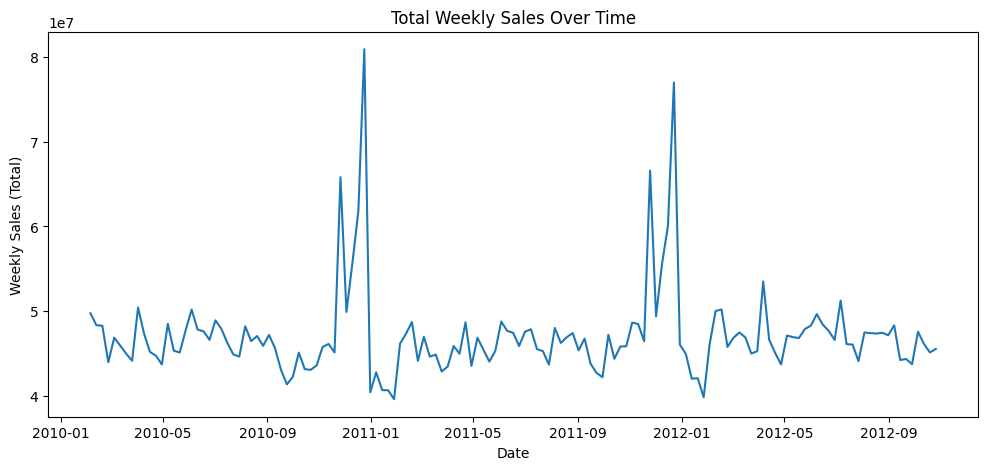

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(weekly_sales)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Total)")
plt.show()

### Rolling Mean

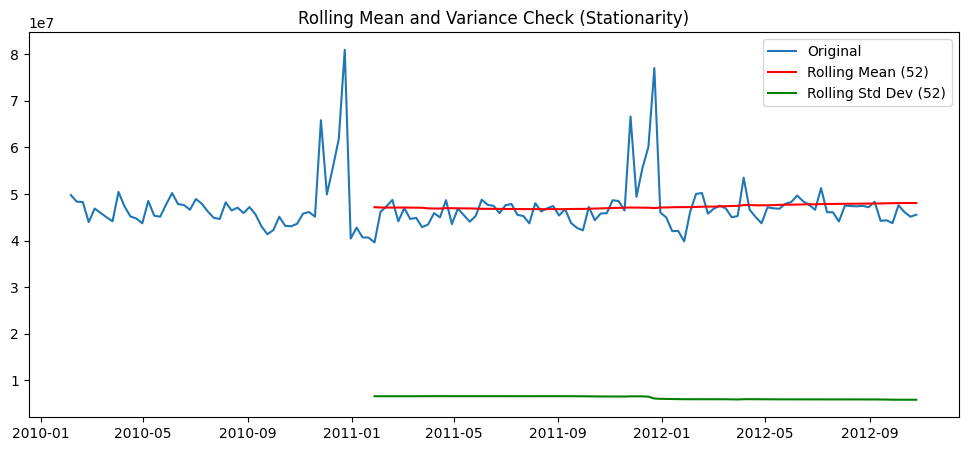

In [ ]:
# Visual stationarity check
rolling_mean = weekly_sales.rolling(52).mean() # 52 week windows (yearly cycle)
rolling_std = weekly_sales.rolling(52).std()

plt.figure(figsize=(12,5))
plt.plot(weekly_sales, label="Original")
plt.plot(rolling_mean, color='red', label="Rolling Mean (52)")
plt.plot(rolling_std, color='green', label="Rolling Std Dev (52)")
plt.title("Rolling Mean and Variance Check (Stationarity)")
plt.legend()
plt.show()

### Decomposition

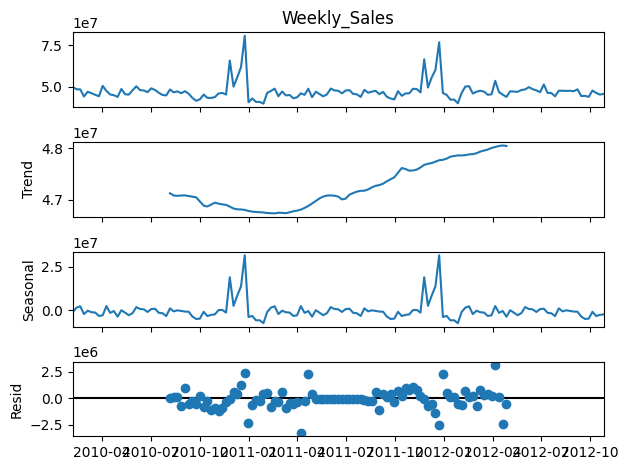

In [ ]:
decomp = seasonal_decompose(weekly_sales, model="additive", period=52)

fig = decomp.plot()
plt.show()

### ADF Test
H0: The series has a unit root (NOT stationary)

H1: The series is stationary

If p-value < 0.05 → reject H0 → stationary

In [ ]:
def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"ADF Test: {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("Stationary (reject H0)")
    else:
        print("Not stationary (fail to reject H0)")

adf_test(weekly_sales, "Weekly Sales")

ADF Test: Weekly Sales
ADF Statistic: -5.908297957186336
p-value: 2.675979158986003e-07
Stationary (reject H0)


### Differencing
Differencing removes trend and stabilizes the mean.

The number of times we difference is the d parameter in ARIMA(p,d,q)

Here we are testing d = 1.

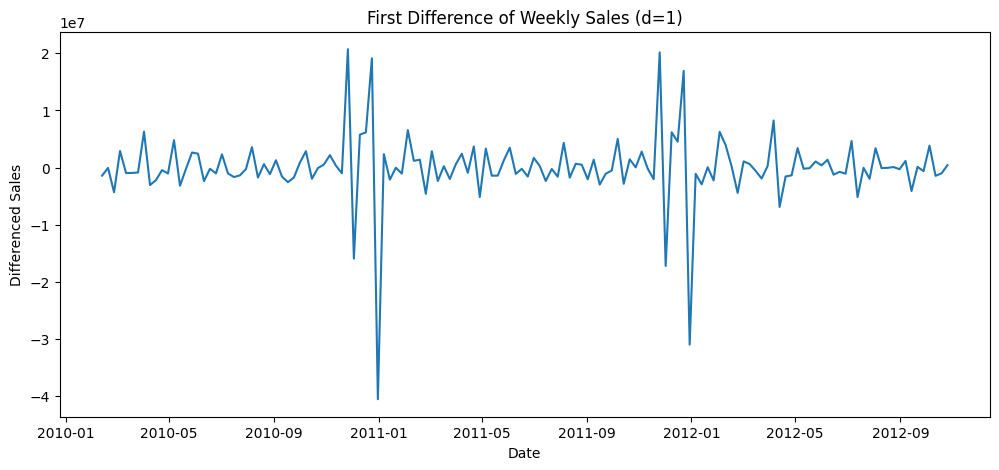

ADF Test: Differenced Weekly Sales (d=1)
ADF Statistic: -6.699469309617218
p-value: 3.922578707076831e-09
Stationary (reject H0)


In [ ]:
sales_diff1 = weekly_sales.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(sales_diff1)
plt.title("First Difference of Weekly Sales (d=1)")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.show()

adf_test(sales_diff1, "Differenced Weekly Sales (d=1)")

### ACF/PACF Plots

ACF helps choose q (Moving Average terms)

PACF helps choose p (Autoregressive terms)

Sharp cutoff in ACF → suggests q

Sharp cutoff in PACF → suggests p

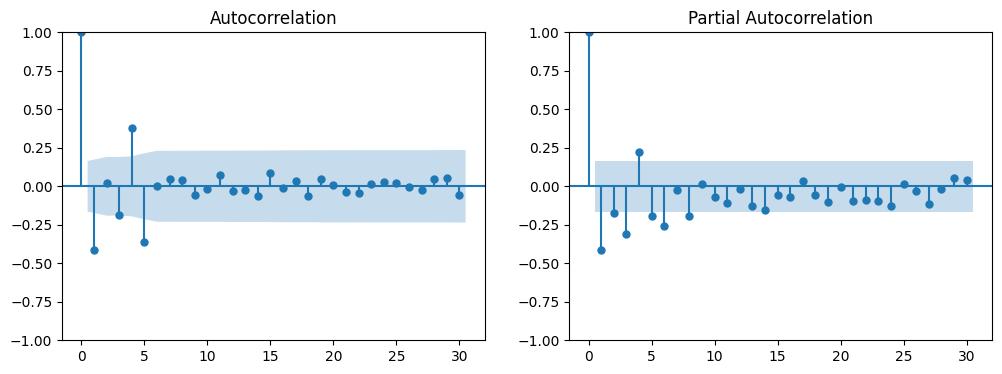

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(sales_diff1, lags=30, ax=axes[0]) # ACF Plot to help us choose q
plot_pacf(sales_diff1, lags=30, ax=axes[1]) # PACF Plot to help us choose p
plt.show()

### Model Fitting

In [ ]:
# Last 12 weeks as test set
train = weekly_sales.iloc[:-12]
test = weekly_sales.iloc[-12:]

print("Train size:", train.shape[0])
print("Test size:", test.shape[0])


Train size: 131
Test size: 12


Based on ACF/PACF inspection:

p = 1 (from PACF behavior)

d = 1 (we differenced once)

q = 1 (from ACF behavior)

In [ ]:
p, d, q = 3, 1, 4

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  142
Model:                 ARIMA(3, 1, 4)   Log Likelihood               -2383.605
Date:                Sun, 15 Feb 2026   AIC                           4783.211
Time:                        21:40:31   BIC                           4806.801
Sample:                    02-05-2010   HQIC                          4792.797
                         - 10-19-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2819      0.441     -0.640      0.522      -1.145       0.582
ar.L2          0.3211      0.286      1.124      0.261      -0.239       0.881
ar.L3          0.2891      0.167      1.733      0.0

### Model Summary Interpretation

AR coefficient (ar.L1): strength of dependence on last week's value

MA coefficient (ma.L1): strength of dependence on last week's error

sigma2: residual variance

AIC: lower is better (used for model comparison)

Ljung-Box p-value > 0.05 suggests residuals are not autocorrelated


### Forecasting

We hold out the last 12 weeks to evaluate model performance.

This prevents training and testing on the same data.


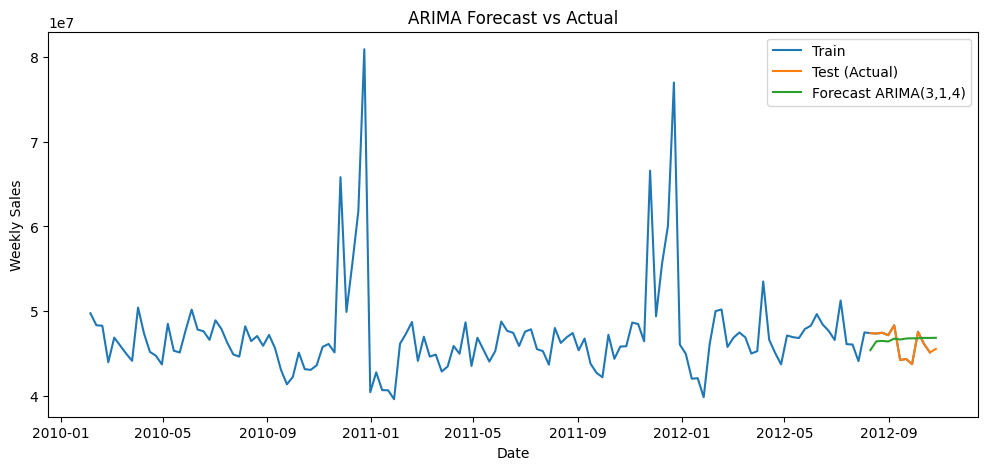

In [ ]:
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # align dates

plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test (Actual)")
plt.plot(forecast, label=f"Forecast ARIMA({p},{d},{q})")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

### RMSE/MAE

RMSE penalizes large errors more heavily

MAE measures average absolute error

Lower values indicate better forecast accuracy


In [ ]:
rmse = sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print(f'RMSE: ${rmse}')
print(f'MAE: ${mae}')

weekly_sales_mean = weekly_sales.mean()
percent_err = (rmse / weekly_sales_mean) * 100
percent_err = percent_err.round(2)
print(f'Percentage Error: {percent_err}%')

RMSE: $1724106.0038538391
MAE: $1551046.5093905746
Percentage Error: 3.66%


#### Analysis:
MAE: On average the forecast is off by about \$1.38 million per week

RMSE > MAE: There are some larger forecast misses (most likely holiday spikes)

PE: Therefore, on average, the forecast is within 4% of total weekly sales. 4% is relatively good for sales forecasting.

Remember, the lower the percentage error the better!

### Residual Diagnostics

A good ARIMA model should leave residuals that look like white noise.

If residual ACF shows significant spikes, model may be underfitting.

If residual variance changes over time, heteroskedasticity may exist.

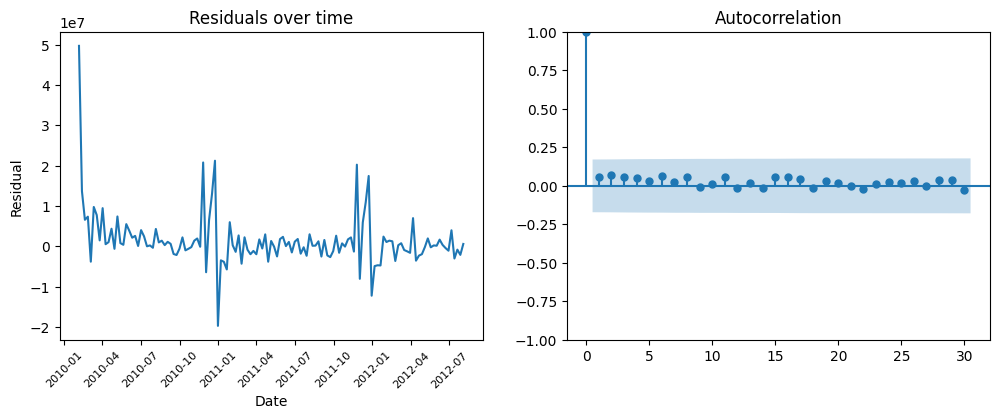

In [ ]:
residuals = model_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(residuals) # Residuals over time
axes[0].set_title("Residuals over time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")
axes[0].tick_params(axis='x', labelsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=45)

plot_acf(residuals, lags=30, ax=axes[1]) # Residual ACF should look like noise
plt.show()

Analyzation:

Residuals Over Time: Since most of the residuals are centered around zero the model captures the general structure well, but due to the spikes, we can conclude that the model struggles on extreme weeks (most likely holidays)

ACF: Most lags are inside the shaded region so the residuals are mostly uncorrelated, but spike around 4-5 suggest that there is mild seasonality

#### Conclusion:

The ARIMA(1,1,1) model achieves an RMSE of \$1.89 million and MAE of \$1.38 million, corresponding to approximately 4.01% of average weekly sales. While the model effectively captures the overall sales level, it fails to reproduce seasonal holiday spikes, suggesting that a seasonal extension (SARIMA) may improve forecast accuracy.

Note: SARIMA is Arima but models data with trends and seasonal patterns

Note: SARIMAX extends this by including external variables to improve accuracy such as the is_holliday feature

### Forecasted Values

In [ ]:
# Forecasted values for the next 10 weeks
forecast_10 = model_fit.forecast(steps=10) # forecast 10 weeks ahead
forecast_table = forecast_10.to_frame(name="Forecasted Weekly Sales") # put into a table
forecast_table["Forecasted Weekly Sales"] = forecast_table["Forecasted Weekly Sales"].round(2) # round values for clean table

forecast_table

,Forecasted Weekly Sales
2012-08-10,45847986.28
2012-08-17,46935183.53
2012-08-24,47050566.76
2012-08-31,47852058.33
2012-09-07,47309872.78
2012-09-14,47258240.91
2012-09-21,47265810.23
2012-09-28,47412120.73
2012-10-05,47324016.93
2012-10-12,47334968.79


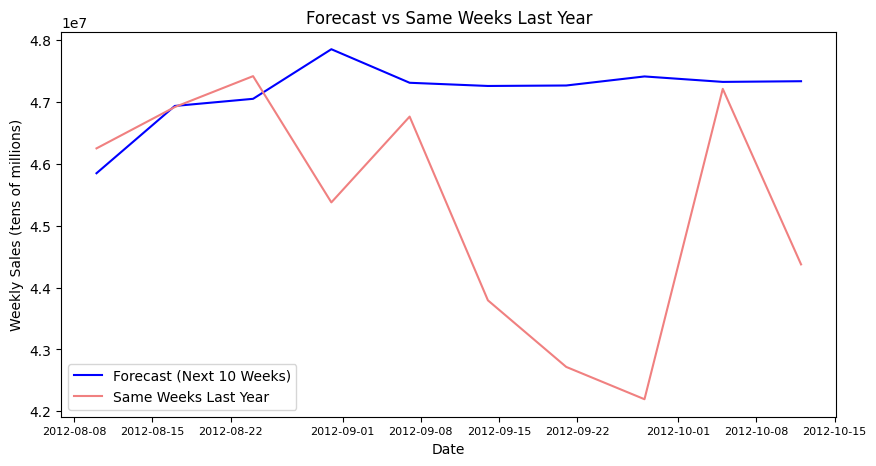

In [ ]:
#Plot to compare next 10 weeks forecasted sales compared
# to last years sales on the same weeks of the year
forecast_dates = forecast_10.index
last_year_dates = forecast_dates - pd.Timedelta(weeks=52)
last_year_values = weekly_sales.loc[last_year_dates]

plt.figure(figsize=(10,5))

# Forecast
plt.plot(forecast_dates, forecast_10, color='blue', label="Forecast (Next 10 Weeks)")

# Last year's values (light red)
plt.plot(forecast_dates, last_year_values.values,
         color='lightcoral', label="Same Weeks Last Year")

plt.title("Forecast vs Same Weeks Last Year")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (tens of millions)")
plt.tick_params(axis='x', labelsize=8)
plt.legend()
plt.show()


RMSE: $1,425,730.82
MAE: $1,163,103.18


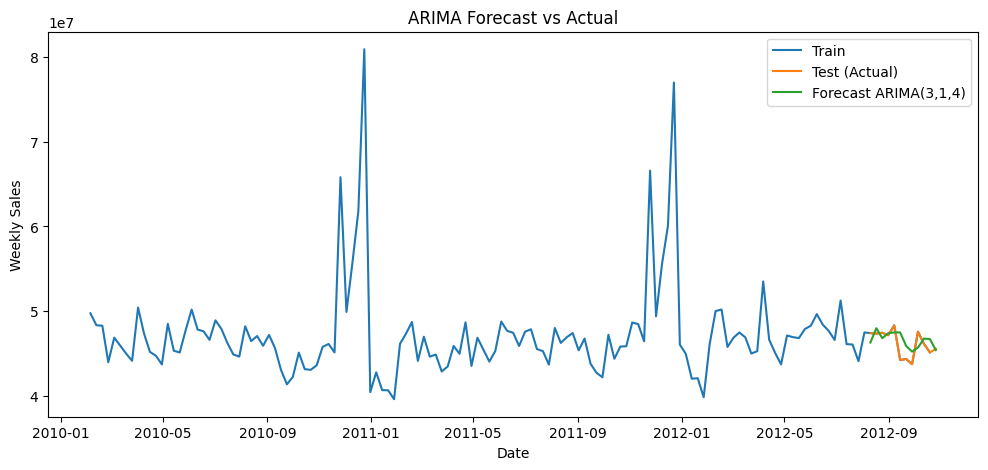

In [ ]:
import warnings
warnings.filterwarnings("ignore")

p, d, q = 3, 1, 4
forecast_lst = []

test_len = 12
for i in range(test_len,0,-1):
    train = weekly_sales.iloc[:-i]
    test = weekly_sales.iloc[-i:]
    model = ARIMA(train, order=(p, d, q))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=1)
    forecast_lst.append(forecast)

test = weekly_sales.iloc[-test_len:]
rmse = sqrt(mean_squared_error(test, forecast_lst))
mae = mean_absolute_error(test, forecast_lst)
print(f'RMSE: ${rmse:,.2f}')
print(f'MAE: ${mae:,.2f}')

plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test (Actual)")
forecast_series = pd.Series(forecast_lst)
forecast_series.index = test.index  # align dates
plt.plot(forecast_series, label=f"Forecast ARIMA({p},{d},{q})")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()




In [ ]:
weekly_sales_mean = weekly_sales.mean()
percent_err = (rmse / weekly_sales_mean) * 100
percent_err = percent_err.round(2)
print(f'Percentage Error: {percent_err}%')

Percentage Error: 3.03%
